# 07 · Unsupervised Learning & Preprocessing

No labels here — just data. Unsupervised methods find structure on their own:

- **Scaling** — the preprocessing that makes distance-based methods work at all.
- **PCA** — compress many features into a few, losing as little information as possible.
- **t-SNE** — a non-linear map for *visualizing* high-dimensional data in 2-D.
- **Clustering** (k-Means, DBSCAN) — group similar samples without being told the groups.

In [1]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import load_digits, load_wine, make_blobs, make_moons

## 1. Scaling: put every feature on the same footing

If one feature ranges 0–1 and another 0–10000, distance-based methods are dominated by the
big one. `StandardScaler` centers each feature to mean 0 and scales to std 1. **Fit the
scaler on training data only**, then apply it everywhere — otherwise test information leaks in.

In [2]:
from sklearn.preprocessing import StandardScaler
wine = load_wine()
Xw = wine.data
print("before scaling — feature means (first 4):", Xw.mean(axis=0)[:4].round(1))
print("before scaling — feature stds  (first 4):", Xw.std(axis=0)[:4].round(1))

Xw_s = StandardScaler().fit_transform(Xw)
print("after  scaling — feature means (first 4):", Xw_s.mean(axis=0)[:4].round(3))
print("after  scaling — feature stds  (first 4):", Xw_s.std(axis=0)[:4].round(3))

before scaling — feature means (first 4): [13.   2.3  2.4 19.5]
before scaling — feature stds  (first 4): [0.8 1.1 0.3 3.3]
after  scaling — feature means (first 4): [ 0.  0. -0. -0.]
after  scaling — feature stds  (first 4): [1. 1. 1. 1.]


## 2. PCA: compression that keeps the signal

Principal Component Analysis finds new axes ("components") ordered by how much variance they
capture. Keeping the top few gives a compact representation — great for speed, denoising, and
plotting. Here we squeeze 13 wine features into 2 and still see the three cultivars separate.

variance explained by 2 components: 0.554


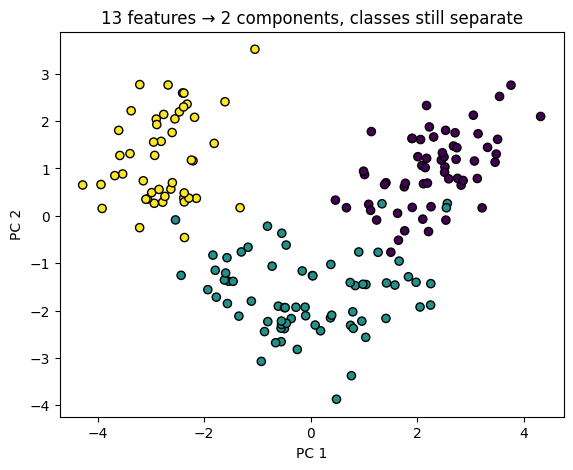

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2).fit(Xw_s)
Xw_2d = pca.transform(Xw_s)
print("variance explained by 2 components:", pca.explained_variance_ratio_.sum().round(3))

plt.figure(figsize=(6.5, 5))
plt.scatter(Xw_2d[:,0], Xw_2d[:,1], c=wine.target, cmap="viridis", edgecolor="k", s=35)
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.title("13 features → 2 components, classes still separate"); plt.show()

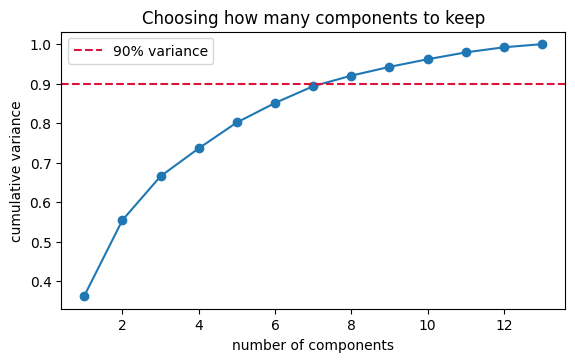

In [4]:
# How many components to keep? The cumulative variance curve tells you.
full = PCA().fit(Xw_s)
cum = np.cumsum(full.explained_variance_ratio_)
plt.figure(figsize=(6.5, 3.6))
plt.plot(range(1, len(cum)+1), cum, "o-")
plt.axhline(0.9, color="crimson", ls="--", label="90% variance")
plt.xlabel("number of components"); plt.ylabel("cumulative variance")
plt.title("Choosing how many components to keep"); plt.legend(); plt.show()

## 3. t-SNE: a map for the eyes

t-SNE is purely for **visualization**: it places similar high-dimensional points near each
other in 2-D. Unlike PCA it captures non-linear structure, but its axes have no meaning and
you shouldn't feed its output to a model. Here it untangles handwritten digits beautifully.

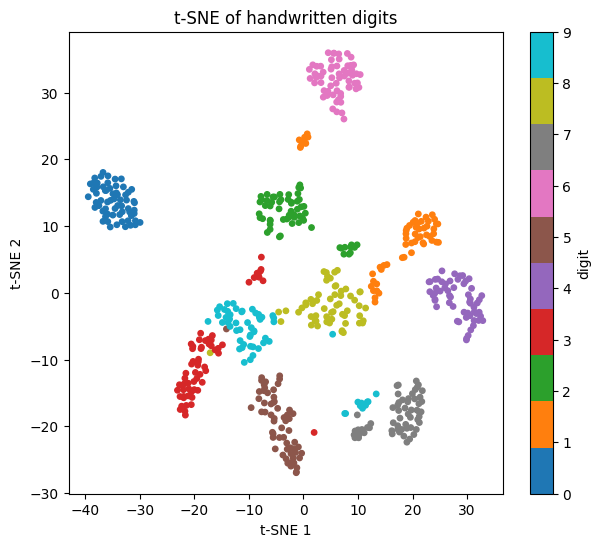

In [5]:
from sklearn.manifold import TSNE
digits = load_digits()
# subset for speed
sub = 600
emb = TSNE(n_components=2, init="pca", learning_rate="auto",
           perplexity=30, random_state=0).fit_transform(digits.data[:sub])

plt.figure(figsize=(7, 6))
sc = plt.scatter(emb[:,0], emb[:,1], c=digits.target[:sub], cmap="tab10", s=15)
plt.colorbar(sc, label="digit"); plt.title("t-SNE of handwritten digits")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2"); plt.show()

## 4. Clustering: groups without labels

- **k-Means** partitions data into `k` round clusters; you must pick `k`. Fast and ubiquitous.
- **DBSCAN** finds clusters of any shape by density and labels sparse points as noise; it finds
  `k` on its own but needs a distance scale.

We show where each shines — and where k-Means fails.

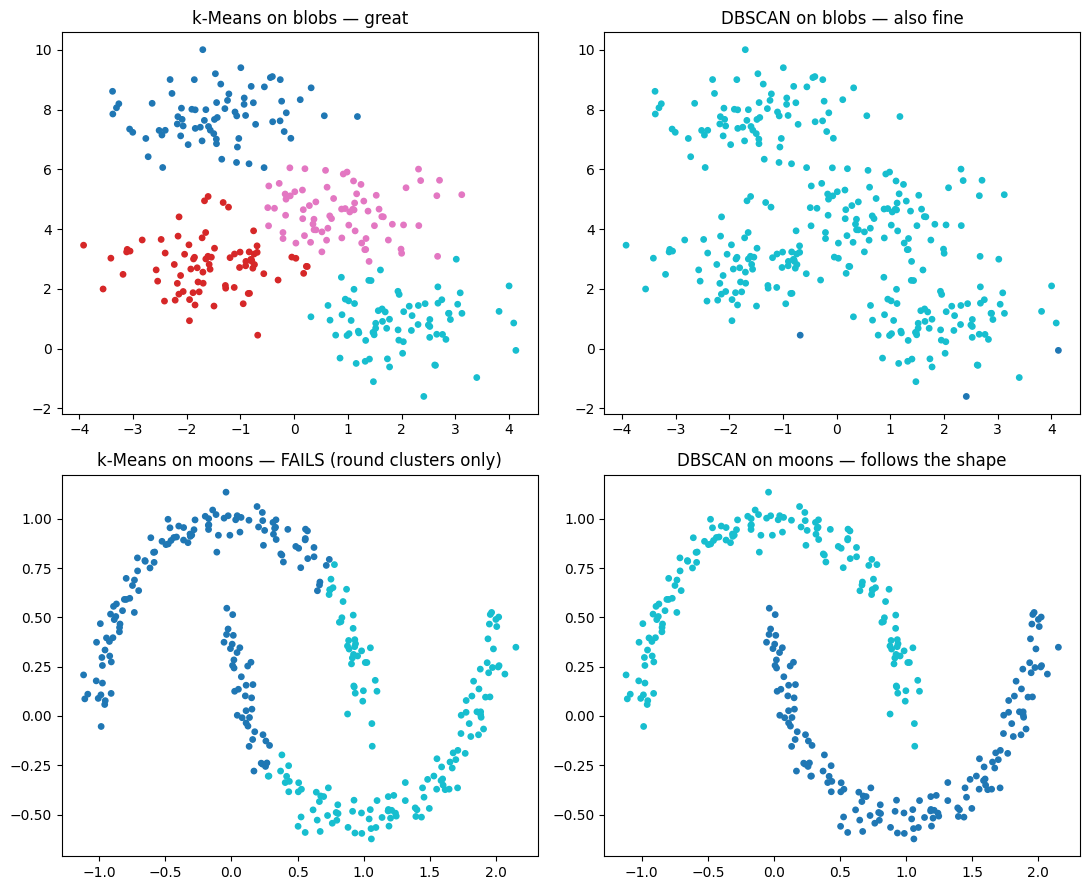

In [6]:
from sklearn.cluster import KMeans, DBSCAN

blobs, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.9, random_state=0)
moons, _ = make_moons(n_samples=300, noise=0.06, random_state=0)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes[0,0].scatter(*blobs.T, c=KMeans(4, n_init=10, random_state=0).fit_predict(blobs), cmap="tab10", s=15)
axes[0,0].set_title("k-Means on blobs — great")
axes[0,1].scatter(*blobs.T, c=DBSCAN(eps=1.0).fit_predict(blobs), cmap="tab10", s=15)
axes[0,1].set_title("DBSCAN on blobs — also fine")
axes[1,0].scatter(*moons.T, c=KMeans(2, n_init=10, random_state=0).fit_predict(moons), cmap="tab10", s=15)
axes[1,0].set_title("k-Means on moons — FAILS (round clusters only)")
axes[1,1].scatter(*moons.T, c=DBSCAN(eps=0.2).fit_predict(moons), cmap="tab10", s=15)
axes[1,1].set_title("DBSCAN on moons — follows the shape")
plt.tight_layout(); plt.show()

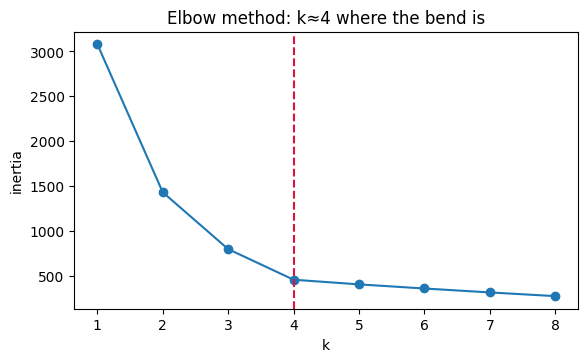

In [7]:
# Picking k for k-Means: the "elbow" in inertia (within-cluster spread)
inertias = [KMeans(k, n_init=10, random_state=0).fit(blobs).inertia_ for k in range(1, 9)]
plt.figure(figsize=(6.5, 3.6))
plt.plot(range(1, 9), inertias, "o-")
plt.xlabel("k"); plt.ylabel("inertia"); plt.title("Elbow method: k≈4 where the bend is")
plt.axvline(4, color="crimson", ls="--"); plt.show()

## Recap

- **Scale first** for any distance-based method; fit the scaler on train only.
- **PCA** compresses features by variance; the cumulative-variance curve picks the count.
- **t-SNE** is for *visualization only* — great pictures, meaningless axes.
- **k-Means** = fast round clusters (pick k via the elbow); **DBSCAN** = arbitrary shapes + noise.

**Next:** `08 — Feature Engineering`, where raw data becomes good features.